# Y.Afisha Marketing Analysis

## Objective
Analyze user behavior, sales patterns and marketing spend for Y.Afisha to optimize investment allocation across acquisition channels.

## Data Sources
- `visits_log_us.csv` — website sessions (Jan 2017 - Dec 2018)
- `orders_log_us.csv` — completed orders
- `costs_us.csv` — marketing spend by acquisition source

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
import numpy as np

In [2]:
# Function to clean column names by stripping whitespace, converting to lowercase, and replacing spaces with underscores
def clean_column_names(df):
    df.columns = (df.columns
                  .str.strip()
                  .str.lower()
                  .str.replace(' ', '_'))
    return df

# 1. Data Loading and Preparation

## Dataset 1: Visits Log

In [3]:
# Load the visits log data
df_visits = pd.read_csv('./data/visits_log_us.csv')

In [4]:
# Display basic information about the DataFrame and its memory usage
df_visits.info(memory_usage='deep')

<class 'pandas.DataFrame'>
RangeIndex: 359400 entries, 0 to 359399
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   Device     359400 non-null  str   
 1   End Ts     359400 non-null  str   
 2   Source Id  359400 non-null  int64 
 3   Start Ts   359400 non-null  str   
 4   Uid        359400 non-null  uint64
dtypes: int64(1), str(3), uint64(1)
memory usage: 71.1 MB


In [5]:
# Check df head to understand the structure of the data
print(df_visits.head(6))

    Device               End Ts  Source Id             Start Ts  \
0    touch  2017-12-20 17:38:00          4  2017-12-20 17:20:00   
1  desktop  2018-02-19 17:21:00          2  2018-02-19 16:53:00   
2    touch  2017-07-01 01:54:00          5  2017-07-01 01:54:00   
3  desktop  2018-05-20 11:23:00          9  2018-05-20 10:59:00   
4  desktop  2017-12-27 14:06:00          3  2017-12-27 14:06:00   
5  desktop  2017-09-03 21:36:00          5  2017-09-03 21:35:00   

                    Uid  
0  16879256277535980062  
1    104060357244891740  
2   7459035603376831527  
3  16174680259334210214  
4   9969694820036681168  
5  16007536194108375387  


In [6]:
# Check options in the 'Device' column
print(df_visits['Device'].value_counts())

Device
desktop    262567
touch       96833
Name: count, dtype: int64


In [7]:
# Check options in the 'Source Id' column
print(df_visits['Source Id'].value_counts())

Source Id
4     101794
3      85610
5      66905
2      47626
1      34121
9      13277
10     10025
7         36
6          6
Name: count, dtype: int64


## Observations
- `Device` has only 2 unique values (`desktop`, `touch`) — should be converted to `category`
- `Source Id` has only 9 unique values — should be converted to `category`
- `Start Ts` / `End Ts` loaded as `str` — should be converted to `datetime`
- `Uid` is `uint64` — appropriate, no change needed
- Column names contain spaces and uppercase — will be standardized to `snake_case`
- Memory usage: 71.1 MB — expected to reduce after optimization

In [8]:
# Reload the data with optimized data types and parse date columns
df_visits = pd.read_csv(
    './data/visits_log_us.csv',
    dtype={'Device': 'category', 'Source Id': 'category'},
    parse_dates=['Start Ts', 'End Ts'])

In [9]:
# Display basic information about the DataFrame and its memory usage after optimization
df_visits.info(memory_usage='deep')

<class 'pandas.DataFrame'>
RangeIndex: 359400 entries, 0 to 359399
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   Device     359400 non-null  category      
 1   End Ts     359400 non-null  datetime64[us]
 2   Source Id  359400 non-null  category      
 3   Start Ts   359400 non-null  datetime64[us]
 4   Uid        359400 non-null  uint64        
dtypes: category(2), datetime64[us](2), uint64(1)
memory usage: 8.9 MB


In [10]:
# Clean column names to avoid issues
df_visits = clean_column_names(df_visits)

In [11]:
# Display the cleaned column names to verify the changes
print(df_visits.columns)

Index(['device', 'end_ts', 'source_id', 'start_ts', 'uid'], dtype='str')


In [12]:
# Check for duplicates
print(f"df_visits number of duplicate rows: {df_visits.duplicated().sum()}")

df_visits number of duplicate rows: 0


In [13]:
# Check for null values
print(f"Null values in each column:\n{df_visits.isnull().sum()}")

Null values in each column:
device       0
end_ts       0
source_id    0
start_ts     0
uid          0
dtype: int64


## Dataset 2: Orders

In [14]:
# Load the orders log data
df_orders = pd.read_csv('./data/orders_log_us.csv')

In [15]:
# Display basic information about the orders DataFrame and its memory usage
df_orders.info(memory_usage='deep')

<class 'pandas.DataFrame'>
RangeIndex: 50415 entries, 0 to 50414
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Buy Ts   50415 non-null  str    
 1   Revenue  50415 non-null  float64
 2   Uid      50415 non-null  uint64 
dtypes: float64(1), str(1), uint64(1)
memory usage: 4.0 MB


In [16]:
# Check df head to understand the structure of the data
print(df_orders.head(6))

                Buy Ts  Revenue                   Uid
0  2017-06-01 00:10:00    17.00  10329302124590727494
1  2017-06-01 00:25:00     0.55  11627257723692907447
2  2017-06-01 00:27:00     0.37  17903680561304213844
3  2017-06-01 00:29:00     0.55  16109239769442553005
4  2017-06-01 07:58:00     0.37  14200605875248379450
5  2017-06-01 08:43:00     0.18  10402394430196413321


## Observations
- `Buy Ts` loaded as `str` — should be converted to `datetime`
- Column names contain spaces and uppercase — will be standardized to `snake_case`
- `Revenue` is `float64` — appropriate for monetary values, no change needed
- `Uid` is `uint64` — appropriate, no change needed
- Memory usage: 4.0 MB — already small, minimal improvement expected after optimization

In [17]:
# Reload the orders data with optimized data types and parse date columns
df_orders = pd.read_csv(
    './data/orders_log_us.csv',
    parse_dates=['Buy Ts'])

In [18]:
# Display basic information about the DataFrame and its memory usage after optimization
df_orders.info(memory_usage='deep')

<class 'pandas.DataFrame'>
RangeIndex: 50415 entries, 0 to 50414
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   Buy Ts   50415 non-null  datetime64[us]
 1   Revenue  50415 non-null  float64       
 2   Uid      50415 non-null  uint64        
dtypes: datetime64[us](1), float64(1), uint64(1)
memory usage: 1.2 MB


In [19]:
# Clean column names to avoid issues
df_orders = clean_column_names(df_orders)

In [20]:
# Display the cleaned column names to verify the changes
print(df_orders.columns)

Index(['buy_ts', 'revenue', 'uid'], dtype='str')


In [21]:
# Check for duplicate rows
print(f"df_orders duplicate rows: {df_orders.duplicated().sum()}")

df_orders duplicate rows: 0


In [22]:
# Check for null values
print(f"Null values in each column:\n{df_orders.isnull().sum()}")

Null values in each column:
buy_ts     0
revenue    0
uid        0
dtype: int64


## Dataset 3: Marketing Costs

In [23]:
# Load the marketing costs data
df_marketing_costs = pd.read_csv('./data/costs_us.csv')

In [24]:
# Display basic information about the marketing costs DataFrame and its memory usage
df_marketing_costs.info(memory_usage='deep')

<class 'pandas.DataFrame'>
RangeIndex: 2542 entries, 0 to 2541
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   source_id  2542 non-null   int64  
 1   dt         2542 non-null   str    
 2   costs      2542 non-null   float64
dtypes: float64(1), int64(1), str(1)
memory usage: 186.3 KB


In [25]:
# Check sources in the 'source_id' column
print(df_marketing_costs['source_id'].value_counts())

source_id
5     364
1     363
2     363
3     363
4     363
9     363
10    363
Name: count, dtype: int64


In [26]:
# Check df head to understand the structure of the data
print(df_marketing_costs.head(6))

   source_id          dt  costs
0          1  2017-06-01  75.20
1          1  2017-06-02  62.25
2          1  2017-06-03  36.53
3          1  2017-06-04  55.00
4          1  2017-06-05  57.08
5          1  2017-06-06  40.39


## Observations
- `source_id` has only 7 unique values — should be converted to `category`
- `dt` loaded as `str` — should be converted to `datetime`
- Column names already in `snake_case` — `clean_column_names()` applied for consistency
- `costs` is `float64` — appropriate for monetary values, no change needed
- Memory usage: 183.3 KB — already small, minimal improvement expected after optimization

In [27]:
# Reload the marketing costs data with optimized data types and parse date columns
df_marketing_costs = pd.read_csv('./data/costs_us.csv', dtype={'source_id': 'category'},
                                 parse_dates=['dt'])

In [28]:
# Display basic information about the DataFrame and its memory usage after optimization
df_marketing_costs.info(memory_usage='deep')

<class 'pandas.DataFrame'>
RangeIndex: 2542 entries, 0 to 2541
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   source_id  2542 non-null   category      
 1   dt         2542 non-null   datetime64[us]
 2   costs      2542 non-null   float64       
dtypes: category(1), datetime64[us](1), float64(1)
memory usage: 43.0 KB


In [29]:
# Clean column names to avoid issues
df_marketing_costs = clean_column_names(df_marketing_costs)

In [30]:
# Display the cleaned column names to verify the changes
print(df_marketing_costs.columns)

Index(['source_id', 'dt', 'costs'], dtype='str')


In [31]:
# Check for duplicate rows
print(
    f"df_marketing_costs duplicate rows: {df_marketing_costs.duplicated().sum()}")

df_marketing_costs duplicate rows: 0


In [32]:
# Check for null values
print(f"Null values in each column:\n{df_marketing_costs.isnull().sum()}")

Null values in each column:
source_id    0
dt           0
costs        0
dtype: int64


## Data Preparation Summary


### Optimization Results
| Dataset | Rows | Before | After | Reduction |
|---|---|---|---|---|
| `df_visits` | 359,400 | 71.1 MB | 8.9 MB | -87% |
| `df_orders` | 50,415 | 4.0 MB | 1.2 MB | -70% |
| `df_marketing_costs` | 2,542 | 183.3 KB | 43.0 KB | -77% |

### Changes Applied
| Dataset | Column | Change |
|---|---|---|
| `df_visits` | `device` | `str` → `category` |
| `df_visits` | `source_id` | `int64` → `category` |
| `df_visits` | `start_ts`, `end_ts` | `str` → `datetime` |
| `df_orders` | `buy_ts` | `str` → `datetime` |
| `df_marketing_costs` | `source_id` | `int64` → `category` |
| `df_marketing_costs` | `dt` | `str` → `datetime` |
| All datasets | column names | standardized to `snake_case` |

### Cross-dataset Observations
- Source IDs `6` and `7` appear in `df_visits` (6 and 36 rows respectively) 
but have no entries in `df_marketing_costs`, suggesting these may represent 
organic or unpaid traffic channels such as direct access or word of mouth.
- No missing values or duplicates found in any dataset.

# 2. Product Analysis

## 2.1 Daily, Weekly and Monthly Active Users (DAU / WAU / MAU)

In [33]:
# Extract year, month, week, and date from 'start_ts' for time-based analysis
df_visits['session_year'] = df_visits['start_ts'].dt.year
df_visits['session_month'] = df_visits['start_ts'].dt.month
df_visits['session_week'] = df_visits['start_ts'].dt.isocalendar().week
df_visits['session_date'] = df_visits['start_ts'].dt.date

In [34]:
# Check first few rows to verify the new columns
print(df_visits.head(6))

    device              end_ts source_id            start_ts  \
0    touch 2017-12-20 17:38:00         4 2017-12-20 17:20:00   
1  desktop 2018-02-19 17:21:00         2 2018-02-19 16:53:00   
2    touch 2017-07-01 01:54:00         5 2017-07-01 01:54:00   
3  desktop 2018-05-20 11:23:00         9 2018-05-20 10:59:00   
4  desktop 2017-12-27 14:06:00         3 2017-12-27 14:06:00   
5  desktop 2017-09-03 21:36:00         5 2017-09-03 21:35:00   

                    uid  session_year  session_month  session_week  \
0  16879256277535980062          2017             12            51   
1    104060357244891740          2018              2             8   
2   7459035603376831527          2017              7            26   
3  16174680259334210214          2018              5            20   
4   9969694820036681168          2017             12            52   
5  16007536194108375387          2017              9            35   

  session_date  
0   2017-12-20  
1   2018-02-19  
2   2017-

In [35]:
# Calculate Daily Active Users (DAU) by counting unique user IDs per session date
dau = df_visits.groupby('session_date').agg(
    {'uid': 'nunique'}).reset_index().rename(columns={'uid': 'dau'})
# Check the first few rows of the DAU DataFrame to verify the results
print(dau.head(6))

  session_date  dau
0   2017-06-01  605
1   2017-06-02  608
2   2017-06-03  445
3   2017-06-04  476
4   2017-06-05  820
5   2017-06-06  797


In [36]:
# Calculate Weekly Active Users (WAU) by counting unique user IDs per session week
wau = df_visits.groupby(['session_year', 'session_week']).agg(
    {'uid': 'nunique'}).reset_index().rename(columns={'uid': 'wau'})
# Check the first few rows of the WAU DataFrame to verify the results
print(wau.head(6))

   session_year  session_week   wau
0          2017            22  2021
1          2017            23  4129
2          2017            24  2812
3          2017            25  2878
4          2017            26  3064
5          2017            27  3294


In [37]:
# Calculate Monthly Active Users (MAU) by counting unique user IDs per session month
mau = df_visits.groupby(['session_year', 'session_month']).agg(
    {'uid': 'nunique'}).reset_index().rename(columns={'uid': 'mau'})
# Check the first few rows of the MAU DataFrame to verify the results
print(mau.head(6))

   session_year  session_month    mau
0          2017              6  13259
1          2017              7  14183
2          2017              8  11631
3          2017              9  18975
4          2017             10  29692
5          2017             11  32797


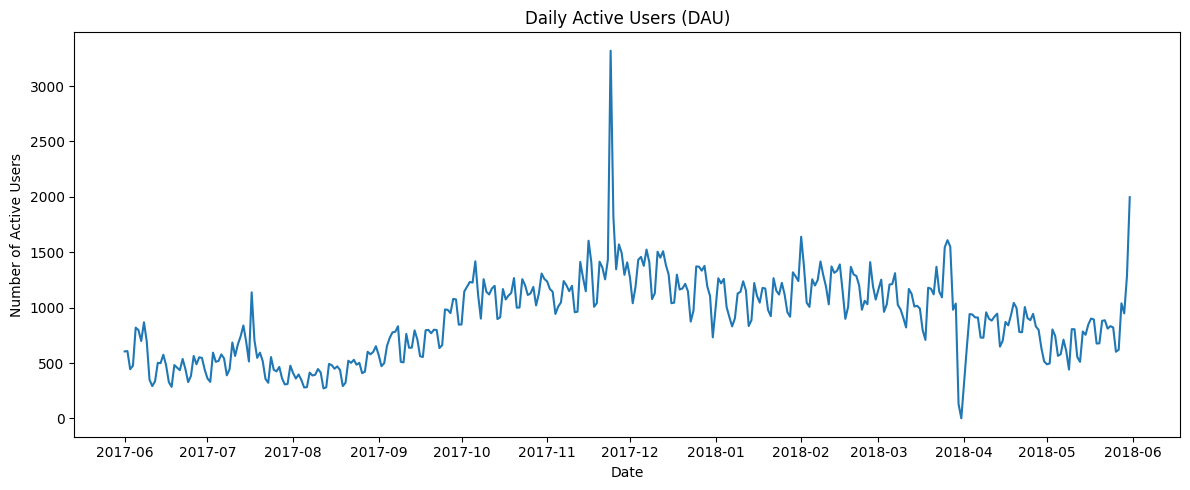

In [38]:
# Plot Daily Active Users (DAU)
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(dau['session_date'], dau['dau'])
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.set_title('Daily Active Users (DAU)')
ax.set_xlabel('Date')
ax.set_ylabel('Number of Active Users')
plt.tight_layout()
plt.show()

### Observations — DAU
- Overall growth in the number of active users throughout the data period (Jun 2017 — Jun 2018)
- Substantial and sustained increase in DAU from summer to autumn 2017, with average daily users approximately doubling
- Regular daily oscillations throughout the period, likely reflecting weekday vs weekend usage patterns
- Anomalous peak in December 2017 — possibly related to a promotional campaign or seasonal event
- Near-zero DAU in April 2018 — likely due to a platform outage or server downtime

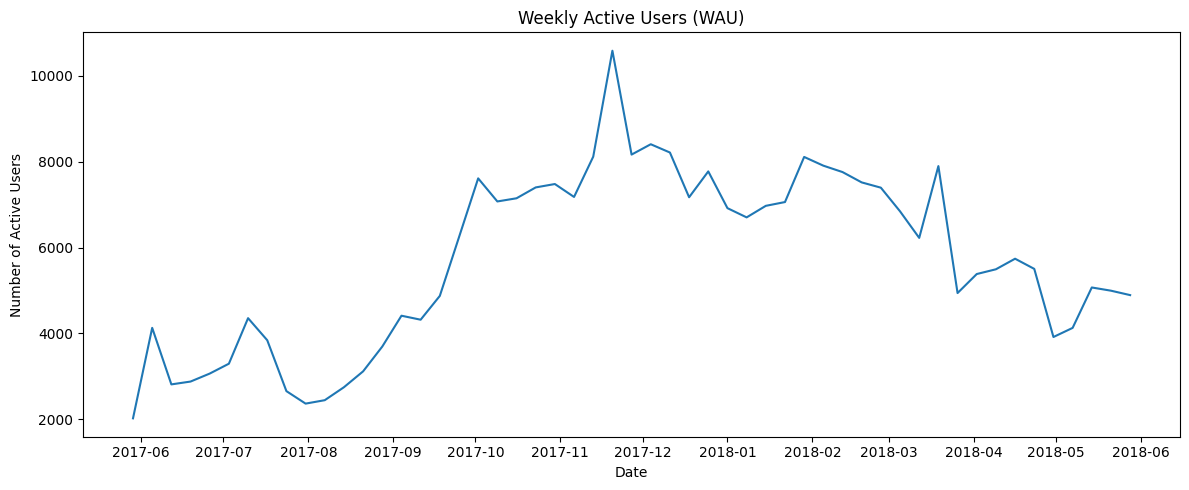

In [39]:
# Plot Weekly Active Users (WAU)
wau['date'] = pd.to_datetime(wau['session_year'].astype(
    str) + '-W' + wau['session_week'].astype(str) + '-1', format='%Y-W%W-%w')
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(wau['date'], wau['wau'])
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.set_title('Weekly Active Users (WAU)')
ax.set_xlabel('Date')
ax.set_ylabel('Number of Active Users')
plt.tight_layout()
plt.show()

### Observations — WAU
- Significant and sustained growth in WAU from June to December 2017, with weekly active users approximately tripling over this period
- Sharp peak in late November / early December 2017 — consistent with the anomalous spike observed in the DAU graph, possibly related to a promotional campaign or seasonal event
- Elevated WAU levels maintained from December 2017 through March 2018
- Sharp drop in April 2018 — consistent with the platform outage identified in the DAU analysis
- No significant recovery after April 2018 — WAU remains below pre-outage levels for the remainder of the period

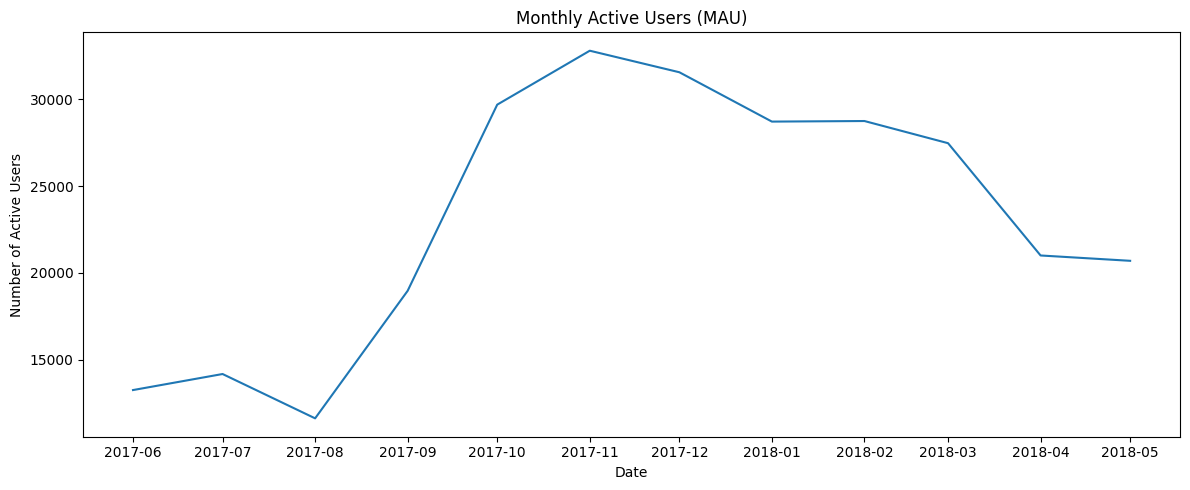

In [40]:
# Plot Monthly Active Users (MAU)
mau['date'] = pd.to_datetime(mau['session_year'].astype(
    str) + '-' + mau['session_month'].astype(str), format='%Y-%m')
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(mau['date'], mau['mau'])
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.set_title('Monthly Active Users (MAU)')
ax.set_xlabel('Date')
ax.set_ylabel('Number of Active Users')
plt.tight_layout()
plt.show()

### Observations — MAU
- Steady growth from June to December 2017, with MAU approximately tripling over this period — consistent with the trend observed in DAU and WAU
- Peak in December 2017, aligning with the anomalous spike identified in the DAU and WAU charts
- Elevated MAU maintained from December 2017 through March 2018, suggesting the growth was not purely seasonal
- Sharp drop in April 2018, consistent with the platform outage identified in the DAU and WAU analysis
- MAU smooths out the daily and weekly noise, confirming that the overall growth and the April 2018 disruption are structural events, not statistical artefacts

## 2.2 Sessions per Day

In [41]:
# Calculate the number of sessions per day
user_data = df_visits.groupby('session_date').agg(
    n_sessions=('uid', 'count')).reset_index()

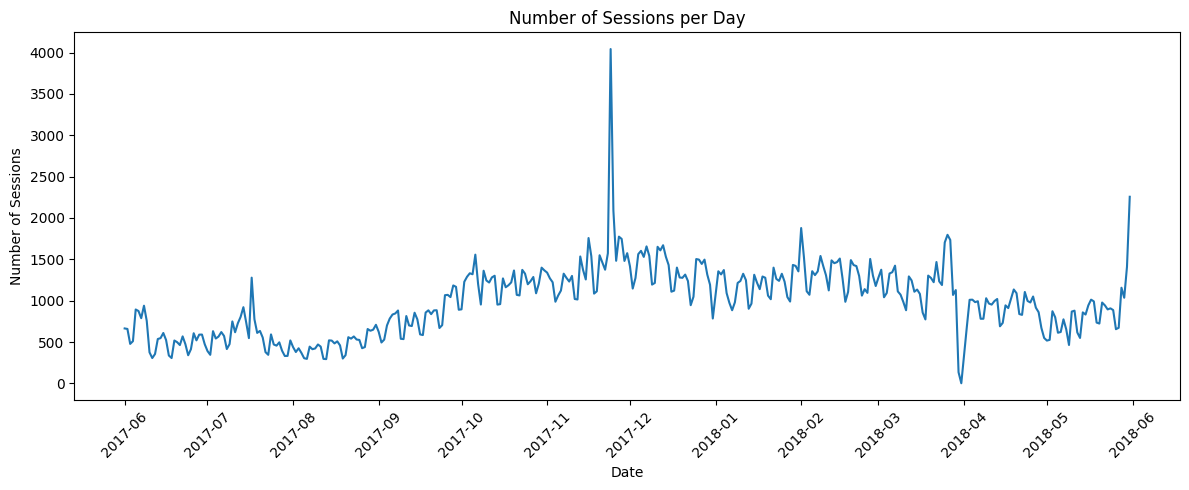

In [42]:
# Plot total number of sessions per day over time
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(user_data['session_date'], user_data['n_sessions'])
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.set_title('Number of Sessions per Day')
ax.set_xlabel('Date')
ax.set_ylabel('Number of Sessions')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Observations — Sessions per Day
- The daily session count closely mirrors the DAU trend, confirming that most users generate exactly one session per day
- Sessions consistently exceed unique users each day, indicating a small fraction of users return more than once daily
- The same growth pattern from summer to autumn 2017, December peak, and April 2018 drop are visible — consistent with the DAU analysis
- Daily oscillations persist, reflecting the weekday vs weekend usage pattern observed in DAU

## 2.3 Session Duration

In [43]:
# Calculate session duration in seconds
df_visits['session_duration_sec'] = (
    df_visits['end_ts'] - df_visits['start_ts']).dt.total_seconds()

In [44]:
# Run descriptive statistics on session duration to understand its distribution
print(df_visits['session_duration_sec'].describe())

count    359400.000000
mean        643.025687
std         997.127761
min       -2760.000000
25%         120.000000
50%         300.000000
75%         840.000000
max       42660.000000
Name: session_duration_sec, dtype: float64


### Data Quality Issues — Session Duration
- At least one session has a negative duration, which is impossible in practice — `end_ts` is recorded before `start_ts`, indicating a data error.
- Maximum duration is unusually large (42,660 seconds, approximately 11.8 hours), likely caused by users leaving the browser open rather than actively using the platform.
- Both cases will be filtered before analysis.

In [45]:
# Get the 99th percentile of session duration to identify potential outliers
p99 = df_visits['session_duration_sec'].quantile(0.99)

In [46]:
# Filter out sessions with duration less than 1 second or greater than the 99th percentile to focus on typical user behavior
df_visits = df_visits[(df_visits['session_duration_sec'] > 0) & (
    df_visits['session_duration_sec'] <= p99)]

In [47]:
# Verify session duration distribution after filtering
print(df_visits['session_duration_sec'].describe())

count    320107.000000
mean        647.840728
std         745.983163
min          19.000000
25%         120.000000
50%         360.000000
75%         900.000000
max        4500.000000
Name: session_duration_sec, dtype: float64


### After Filtering
- After filtering, ~39,000 rows were removed using two filters: 
sessions with negative duration (data errors) and outliers above the 99th percentile
- Min is now 19 seconds — consistent with a quick website visit
- Median is 360 seconds (~6 minutes) — sufficient time to browse and purchase a ticket
- Max is 4,500 seconds (~75 minutes) — plausible for an engaged user browsing multiple events

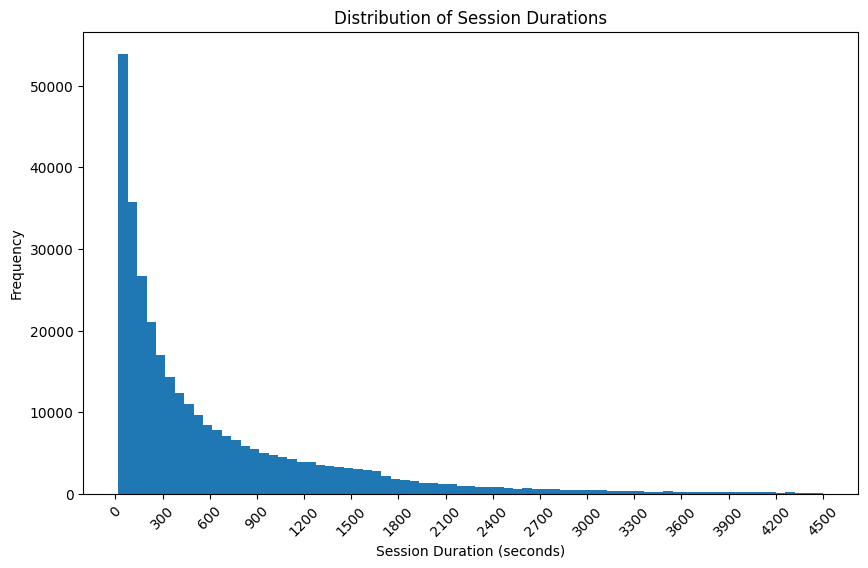

In [48]:
# Plot duration of sessions
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(df_visits['session_duration_sec'], bins=75)
plt.xticks(rotation=45)
ax.set_xlabel('Session Duration (seconds)')
ax.set_ylabel('Frequency')
ax.set_title('Distribution of Session Durations')
# Set x-axis ticks every 5 minutes (300 seconds)
ax.xaxis.set_major_locator(plt.MultipleLocator(300))
plt.show()

### Observations — Session Duration
- The distribution is right-skewed, indicating that most users spend a short 
amount of time on the platform — typical behaviour for a ticket sales website 
where users visit with a specific purchase intent
- The median session duration is ~6 minutes, which is consistent with the time 
needed to browse events and complete a purchase

## 2.4 How Often Do Users Return?

In [49]:
# Calculate the timestamp of the first visit for each user to analyze user retention and cohort behavior
first_visit = df_visits.groupby('uid')['start_ts'].min()
first_visit.name = 'first_visit_ts'

In [50]:
# Join the first visit timestamp back to the original visits DataFrame
df_visits = df_visits.join(first_visit, on='uid')

In [51]:
# Extract week and year of the current visit and the first visit to analyze user retention and cohort behavior
df_visits['visit_week'] = df_visits['start_ts'].dt.isocalendar().week
df_visits['visit_year'] = df_visits['start_ts'].dt.year
df_visits['first_visit_week'] = df_visits['first_visit_ts'].dt.isocalendar().week
df_visits['first_visit_year'] = df_visits['first_visit_ts'].dt.year

In [52]:
# Calculate weeks elapsed between each visit and the user's first visit
df_visits['cohort_lifetime'] = (
    pd.to_datetime(df_visits['visit_year'].astype(str) + '-W' + df_visits['visit_week'].astype(str) + '-1', format='%Y-W%W-%w') -
    pd.to_datetime(df_visits['first_visit_year'].astype(
        str) + '-W' + df_visits['first_visit_week'].astype(str) + '-1', format='%Y-W%W-%w')
)

In [53]:
# Convert cohort lifetime from timedelta to weeks and round to the nearest integer
df_visits['cohort_lifetime'] = df_visits['cohort_lifetime'] / \
    np.timedelta64(1, 'W')
df_visits['cohort_lifetime'] = df_visits['cohort_lifetime'].round().astype(int)

In [54]:
# Create a cohort column based on the first visit year and week
df_visits['cohort'] = pd.to_datetime(
    df_visits['first_visit_year'].astype(str) + '-W' +
    df_visits['first_visit_week'].astype(str) + '-1',
    format='%Y-W%W-%w'
)

In [55]:
# Group by cohort lifetime, first visit year, and first visit week to calculate the number of unique users in each cohort over time
grouped_cohorts = df_visits.groupby(['cohort_lifetime', 'cohort']).agg(
    {'uid': 'nunique'}).reset_index().rename(columns={'uid': 'n_users'})

In [56]:
# Extract the number of users in the initial week (cohort lifetime = 0) for each cohort to analyze user retention and cohort behavior
initial_users = grouped_cohorts[grouped_cohorts['cohort_lifetime'] == 0][[
    'cohort', 'n_users']]

# rename the n_users column to initial_users for clarity
initial_users = initial_users.rename(columns={'n_users': 'initial_users'})

In [57]:
# merge the initial users back to the grouped cohorts DataFrame to calculate retention rates
grouped_cohorts = grouped_cohorts.merge(initial_users, on='cohort', how='left')

In [58]:
# calculate retention rate
grouped_cohorts['retention_rate'] = grouped_cohorts['n_users'] / \
    grouped_cohorts['initial_users']

In [59]:
# Pivot retention rates: rows = cohorts, columns = lifetime weeks
cohort_pivot = grouped_cohorts.pivot_table(
    index='cohort', columns='cohort_lifetime', values='retention_rate', aggfunc='mean')

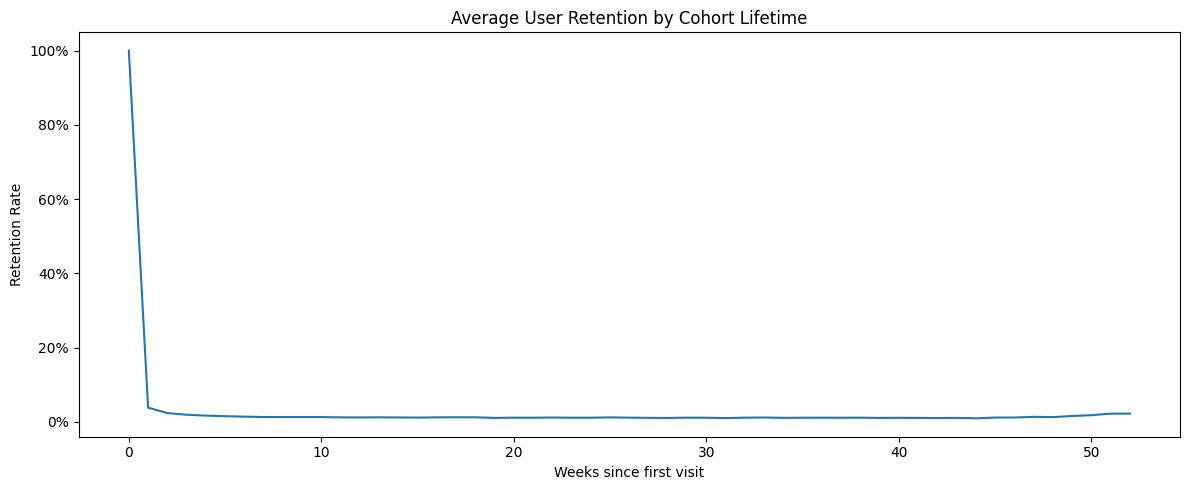

In [60]:
# Plot average retention rate across all cohorts by week
retention_by_lifetime = grouped_cohorts.groupby(
    'cohort_lifetime')['retention_rate'].mean()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(retention_by_lifetime.index, retention_by_lifetime.values)
ax.set_title('Average User Retention by Cohort Lifetime')
ax.set_xlabel('Weeks since first visit')
ax.set_ylabel('Retention Rate')
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda y, _: '{:.0%}'.format(y)))
plt.tight_layout()
plt.show()

### Observations — User Retention
- Retention drops sharply after week 1, indicating that most users do not return after their first visit — typical for a ticket sales platform where purchases are infrequent
- By week 4, retention stabilises at a low level, suggesting a small but consistent core of repeat users
- The low long-term retention confirms that Y.Afisha relies heavily on acquiring new users rather than retaining existing ones — marketing spend efficiency is therefore critical